## Cell 1: imports + data load

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_pickle('C:/Users/santh/battery-rul-project/data/processed/feature_battery_data.pkl')

feature_cols = ['v_mean', 'v_std', 'v_min', 'v_max', 'v_slope', 'v_range',
                'i_mean', 'i_std', 't_mean', 't_max', 't_min', 't_rise',
                'capacity_delta', 'v_mean_delta', 't_rise_delta']

X = df[feature_cols]
y = df['SOH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

## Cell 2:  baseline (default params) RandomForest + XGBoost

In [2]:
rf_default = RandomForestRegressor(random_state=42)
xgb_default = XGBRegressor(random_state=42)

rf_default.fit(X_train, y_train)
xgb_default.fit(X_train, y_train)

for name, model in [('Random Forest (default)', rf_default), ('XGBoost (default)', xgb_default)]:
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}: RMSE={rmse:.4f}, R2={r2:.4f}")

Random Forest (default): RMSE=0.0110, R2=0.9892
XGBoost (default): RMSE=0.0111, R2=0.9891


## Cell 3: hyperparameter tuning: Random Forest (GridSearchCV)

In [3]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV RMSE:", -rf_grid.best_score_)

Best RF params: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV RMSE: 0.014566721560789957


## Cell 4: hyperparameter tuning: XGBoost (GridSearchCV)

In [4]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV RMSE:", -xgb_grid.best_score_)

Best XGB params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
Best XGB CV RMSE: 0.013354492835549552


## Cell 5: Final evaluation of the tuned models on the test set.

In [5]:
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

final_results = []
for name, model in [('Random Forest (tuned)', best_rf), ('XGBoost (tuned)', best_xgb)]:
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    final_results.append({'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

ensemble_results_df = pd.DataFrame(final_results)
ensemble_results_df

,model,RMSE,MAE,R2
0,Random Forest (tuned),0.010885,0.007230,0.989438
1,XGBoost (tuned),0.010545,0.006508,0.990087


## Cell 6: baseline vs ensemble comparison (combined table)

In [6]:
baseline_results_df = pd.read_csv('C:/Users/santh/battery-rul-project/results/baseline_model_results.csv')

combined_df = pd.concat([baseline_results_df, ensemble_results_df], ignore_index=True)
combined_df = combined_df.sort_values('RMSE').reset_index(drop=True)
combined_df

,model,RMSE,MAE,R2
0,Polynomial Regression (deg=2),0.007801,0.005375,0.994575
1,XGBoost (tuned),0.010545,0.006508,0.990087
2,Random Forest (tuned),0.010885,0.007230,0.989438
3,Linear Regression,0.014265,0.010957,0.981859
4,Ridge Regression,0.014885,0.011624,0.980248
5,SVR (RBF kernel),0.016380,0.010524,0.976082
6,Lasso Regression,0.027543,0.020003,0.932372


## Cell 7: Feature importance (RandomForest — a direct answer to my earlier doubt, 'which feature contributed the most?')

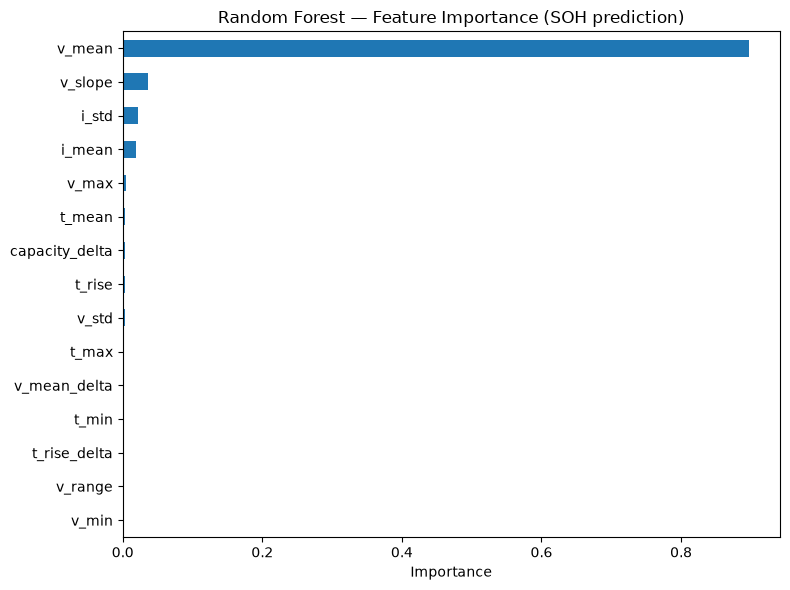

In [7]:
import matplotlib.pyplot as plt

importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Random Forest — Feature Importance (SOH prediction)')
plt.tight_layout()
plt.show()

## Cell 8: save final results

In [8]:
os.makedirs('C:/Users/santh/battery-rul-project/results', exist_ok=True)
combined_df.to_csv('C:/Users/santh/battery-rul-project/results/final_model_comparison.csv', index=False)
print("Saved final comparison.")

Saved final comparison.


## Cell 9: Redefining features without capacity_delta

In [9]:
feature_cols_no_leak = ['v_mean', 'v_std', 'v_min', 'v_max', 'v_slope', 'v_range',
                         'i_mean', 'i_std', 't_mean', 't_max', 't_min', 't_rise',
                         'v_mean_delta', 't_rise_delta']   # capacity_delta removed

X2 = df[feature_cols_no_leak]
y2 = df['SOH']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, shuffle=True)

## Cell 10: Re-training and evaluating all models (RandomForest, XGBoost, Polynomial — can stick to the top 3, or run all 7 if desired)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

no_leak_models = {
    'Polynomial Regression (deg=2)': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    'Random Forest (default)': RandomForestRegressor(random_state=42),
    'XGBoost (default)': XGBRegressor(random_state=42),
}

no_leak_results = []
for name, model in no_leak_models.items():
    model.fit(X2_train, y2_train)
    preds = model.predict(X2_test)
    rmse = np.sqrt(mean_squared_error(y2_test, preds))
    mae = mean_absolute_error(y2_test, preds)
    r2 = r2_score(y2_test, preds)
    no_leak_results.append({'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

no_leak_df = pd.DataFrame(no_leak_results).sort_values('RMSE')
no_leak_df

,model,RMSE,MAE,R2
0,Polynomial Regression (deg=2),0.009240,0.006054,0.992389
2,XGBoost (default),0.011170,0.007097,0.988878
1,Random Forest (default),0.011503,0.007312,0.988204


## Cell 9: Redefining features without capacity_delta (with scaler)

In [9]:
feature_cols_no_leak = ['v_mean', 'v_std', 'v_min', 'v_max', 'v_slope', 'v_range',
                         'i_mean', 'i_std', 't_mean', 't_max', 't_min', 't_rise',
                         'v_mean_delta', 't_rise_delta']   # capacity_delta removed

X2 = df[feature_cols_no_leak]
y2 = df['SOH']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, shuffle=True)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

## Cell 10: 7 models train + evaluate

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

no_leak_models = {
    'Linear Regression': (LinearRegression(), True),
    'Ridge Regression': (Ridge(alpha=1.0), True),
    'Lasso Regression': (Lasso(alpha=0.01), True),
    'Polynomial Regression (deg=2)': (make_pipeline(PolynomialFeatures(degree=2), LinearRegression()), True),
    'SVR (RBF kernel)': (SVR(kernel='rbf', C=1.0, epsilon=0.01), True),
    'Random Forest (default)': (RandomForestRegressor(random_state=42), False),
    'XGBoost (default)': (XGBRegressor(random_state=42), False),
}
# True = use scaled data, False = raw data (tree models don't need scaling)

no_leak_results = []
for name, (model, needs_scaling) in no_leak_models.items():
    if needs_scaling:
        model.fit(X2_train_scaled, y2_train)
        preds = model.predict(X2_test_scaled)
    else:
        model.fit(X2_train, y2_train)
        preds = model.predict(X2_test)

    rmse = np.sqrt(mean_squared_error(y2_test, preds))
    mae = mean_absolute_error(y2_test, preds)
    r2 = r2_score(y2_test, preds)
    no_leak_results.append({'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

no_leak_df = pd.DataFrame(no_leak_results).sort_values('RMSE').reset_index(drop=True)
no_leak_df

,model,RMSE,MAE,R2
0,Polynomial Regression (deg=2),0.006504,0.004815,0.996229
1,XGBoost (default),0.011170,0.007097,0.988878
2,Random Forest (default),0.011503,0.007312,0.988204
3,SVR (RBF kernel),0.013196,0.009283,0.984478
4,Linear Regression,0.014247,0.010955,0.981905
5,Ridge Regression,0.014852,0.011619,0.980337
6,Lasso Regression,0.027543,0.020003,0.932372


## Cell 11: Setting up features and splits for the RUL target.

In [12]:
feature_cols_final = ['v_mean', 'v_std', 'v_min', 'v_max', 'v_slope', 'v_range',
                       'i_mean', 'i_std', 't_mean', 't_max', 't_min', 't_rise',
                       'v_mean_delta', 't_rise_delta']   # capacity_delta removed (found it to be redundant)

X_rul = df[feature_cols_final]
y_rul = df['RUL']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_rul, y_rul, test_size=0.2, random_state=42, shuffle=True)

scaler_rul = StandardScaler()
Xr_train_scaled = scaler_rul.fit_transform(Xr_train)
Xr_test_scaled = scaler_rul.transform(Xr_test)

## Cell 12: All 7 models train + evaluate

In [13]:
rul_models = {
    'Linear Regression': (LinearRegression(), True),
    'Ridge Regression': (Ridge(alpha=1.0), True),
    'Lasso Regression': (Lasso(alpha=0.01), True),
    'Polynomial Regression (deg=2)': (make_pipeline(PolynomialFeatures(degree=2), LinearRegression()), True),
    'SVR (RBF kernel)': (SVR(kernel='rbf', C=1.0, epsilon=0.01), True),
    'Random Forest (default)': (RandomForestRegressor(random_state=42), False),
    'XGBoost (default)': (XGBRegressor(random_state=42), False),
}

rul_results = []
for name, (model, needs_scaling) in rul_models.items():
    if needs_scaling:
        model.fit(Xr_train_scaled, yr_train)
        preds = model.predict(Xr_test_scaled)
    else:
        model.fit(Xr_train, yr_train)
        preds = model.predict(Xr_test)

    rmse = np.sqrt(mean_squared_error(yr_test, preds))
    mae = mean_absolute_error(yr_test, preds)
    r2 = r2_score(yr_test, preds)
    rul_results.append({'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

rul_results_df = pd.DataFrame(rul_results).sort_values('RMSE').reset_index(drop=True)
rul_results_df

c:\Users\santh\battery-rul-project\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.018229e+05, tolerance: 1.634e+03
  model = cd_fast.enet_coordinate_descent(


,model,RMSE,MAE,R2
0,Random Forest (default),21.831384,15.187891,0.983669
1,Polynomial Regression (deg=2),22.760790,16.678336,0.982249
2,XGBoost (default),24.192004,16.461308,0.979947
3,Ridge Regression,61.803721,52.193551,0.869121
4,Lasso Regression,62.487512,51.925900,0.866209
5,Linear Regression,62.531782,51.922154,0.866019
6,SVR (RBF kernel),140.052262,115.328617,0.327920


## Cell 13: Hyperparameter tuning for the best RUL model (using GridSearchCV, planning to use XGBoost)

In [14]:
xgb_rul_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_grid,   # already defined earlier in notebook
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
xgb_rul_grid.fit(Xr_train, yr_train)

print("Best XGB (RUL) params:", xgb_rul_grid.best_params_)

best_xgb_rul = xgb_rul_grid.best_estimator_
preds = best_xgb_rul.predict(Xr_test)
print("Tuned XGBoost RUL — RMSE:", np.sqrt(mean_squared_error(yr_test, preds)), "R2:", r2_score(yr_test, preds))

Best XGB (RUL) params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
Tuned XGBoost RUL — RMSE: 22.656810337898403 R2: 0.9824110865592957


## Cell 14: Visualize Actual vs Predicted RUL

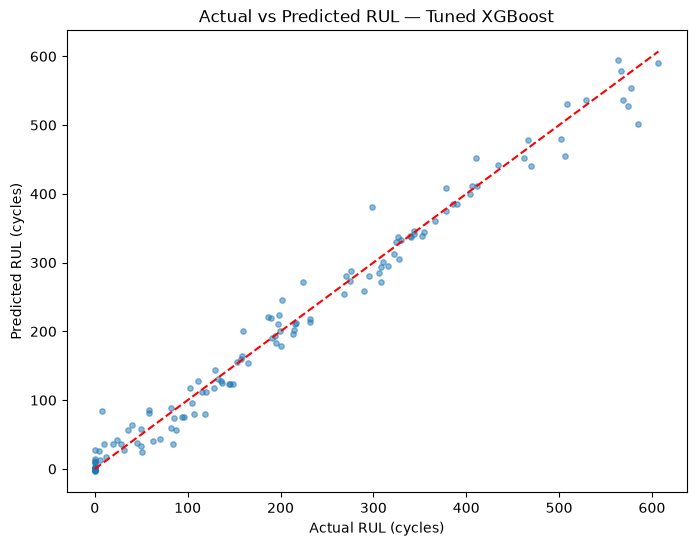

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(yr_test, preds, alpha=0.5, s=15)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title('Actual vs Predicted RUL — Tuned XGBoost')
plt.show()

## Cell 15: save RUL results

In [16]:
rul_results_df.to_csv('C:/Users/santh/battery-rul-project/results/rul_model_results.csv', index=False)
print("Saved RUL results.")

Saved RUL results.


## Cell 16: GridSearchCV for Random Forest (RUL)

In [17]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

rf_rul_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_rul_grid.fit(Xr_train, yr_train)

print("Best RF (RUL) params:", rf_rul_grid.best_params_)
best_rf_rul = rf_rul_grid.best_estimator_
preds_rf = best_rf_rul.predict(Xr_test)
print("Tuned RF RUL — RMSE:", np.sqrt(mean_squared_error(yr_test, preds_rf)), "R2:", r2_score(yr_test, preds_rf))

Best RF (RUL) params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Tuned RF RUL — RMSE: 21.831384035517537 R2: 0.9836693528893917


## Cell 17: Actual vs Predicted plot, tuned RF vs tuned XGBoost side by side

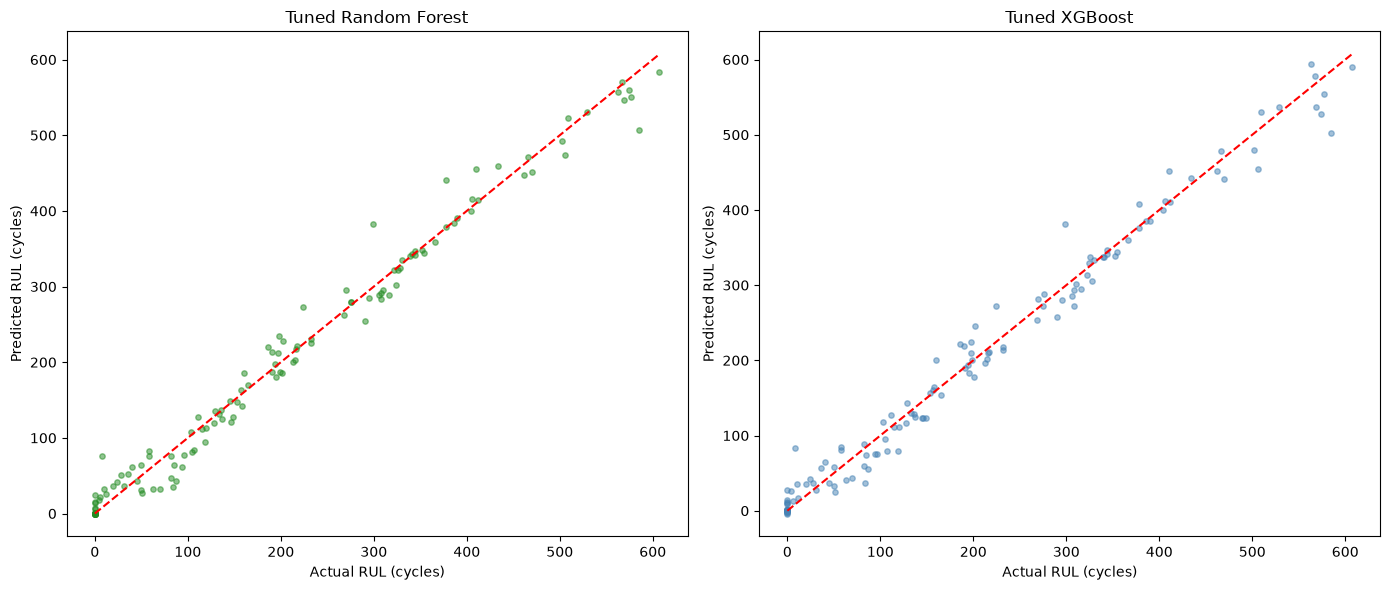

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].scatter(yr_test, preds_rf, alpha=0.5, s=15, color='forestgreen')
axes[0].plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
axes[0].set_xlabel('Actual RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].set_title('Tuned Random Forest')

axes[1].scatter(yr_test, preds, alpha=0.5, s=15, color='steelblue')  # preds = tuned XGBoost preds from Cell 14
axes[1].plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
axes[1].set_xlabel('Actual RUL (cycles)')
axes[1].set_ylabel('Predicted RUL (cycles)')
axes[1].set_title('Tuned XGBoost')

plt.tight_layout()
plt.show()

## Cell 18: final comparison table + save

In [19]:
final_comparison = pd.DataFrame([
    {'model': 'Random Forest (tuned)', 'RMSE': np.sqrt(mean_squared_error(yr_test, preds_rf)), 
     'MAE': mean_absolute_error(yr_test, preds_rf), 'R2': r2_score(yr_test, preds_rf)},
    {'model': 'XGBoost (tuned)', 'RMSE': np.sqrt(mean_squared_error(yr_test, preds)), 
     'MAE': mean_absolute_error(yr_test, preds), 'R2': r2_score(yr_test, preds)},
])
final_comparison = final_comparison.sort_values('RMSE').reset_index(drop=True)
print(final_comparison)

final_comparison.to_csv('C:/Users/santh/battery-rul-project/results/rul_final_comparison.csv', index=False)
print("Saved final comparison.")

                   model       RMSE        MAE        R2
0  Random Forest (tuned)  21.831384  15.187891  0.983669
1        XGBoost (tuned)  22.656810  16.392479  0.982411
Saved final comparison.
